# Project 4: NLP & Sentiment Analysis
### Industrial Training Kit — Decodelabe

---

**Goal:** Program a machine to read and mathematically categorize unstructured human text (e.g., product reviews).

### Production Pipeline Blueprint
| Step | Stage | Input → Output |
|------|-------|----------------|
| 1 | **Stop-Words** | Exclude negations ('not') from default NLTK dictionaries |
| 2 | **Lemmatization** | Map Treebank tags → WordNet POS tags for accurate morphological reduction |
| 3 | **Vectorization** | TF-IDF with Unigrams/Bigrams, limit `max_features` |
| 4 | **Memory Optimization** | Store matrices in SciPy CSR Sparse format |
| 5 | **Inference** | MultinomialNB or ComplementNB with Laplace smoothing |

---


## Step 0 — Install & Import Dependencies

In [13]:
# Install required libraries (run once)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

install("nltk")
install("scikit-learn")
install("scipy")
install("pandas")
install("matplotlib")
install("seaborn")

print(" All libraries installed.")


 All libraries installed.


In [14]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# NLTK
import nltk
nltk.download("movie_reviews", quiet=True)
nltk.download("stopwords",     quiet=True)
nltk.download("punkt",         quiet=True)
nltk.download("punkt_tab",     quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet",       quiet=True)
nltk.download("omw-1.4",       quiet=True)

from nltk.corpus       import movie_reviews, stopwords
from nltk.tokenize     import word_tokenize
from nltk.stem         import WordNetLemmatizer
from nltk.corpus       import wordnet
from nltk              import pos_tag

In [16]:
# Scikit-learn
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes      import MultinomialNB, ComplementNB
from sklearn.svm              import LinearSVC
from sklearn.metrics          import (accuracy_score, classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline         import Pipeline

# SciPy sparse matrices
import scipy.sparse as sp

print(" All imports successful.")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")
import sklearn; print(f"   Sklearn : {sklearn.__version__}")


 All imports successful.
   NumPy   : 2.1.3
   Pandas  : 2.2.3
   Sklearn : 1.6.1


---
## Step 1 — Ingest: Load the Dataset

We use the **NLTK Movie Reviews** corpus (2,000 labelled reviews — 1,000 positive, 1,000 negative).  
This is a perfectly balanced dataset, ideal for `MultinomialNB`.


In [17]:
# ── Load NLTK Movie Reviews corpus ────────────────────────────────────────────
documents = []
labels    = []

for category in movie_reviews.categories():          # 'neg', 'pos'
    for fileid in movie_reviews.fileids(category):
        raw_text = movie_reviews.raw(fileid)
        documents.append(raw_text)
        labels.append(1 if category == "pos" else 0) # 1=Positive, 0=Negative

df = pd.DataFrame({"review": documents, "sentiment": labels})

print(f"Total reviews : {len(df)}")
print(f"Class balance :")
print(df["sentiment"].value_counts().rename({1: "Positive", 0: "Negative"}))
print("\nSample review (first 300 chars):")
print(df["review"].iloc[0][:300])


Total reviews : 2000
Class balance :
sentiment
Negative    1000
Positive    1000
Name: count, dtype: int64

Sample review (first 300 chars):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


## Step 1b — Exploratory Data Analysis (EDA)

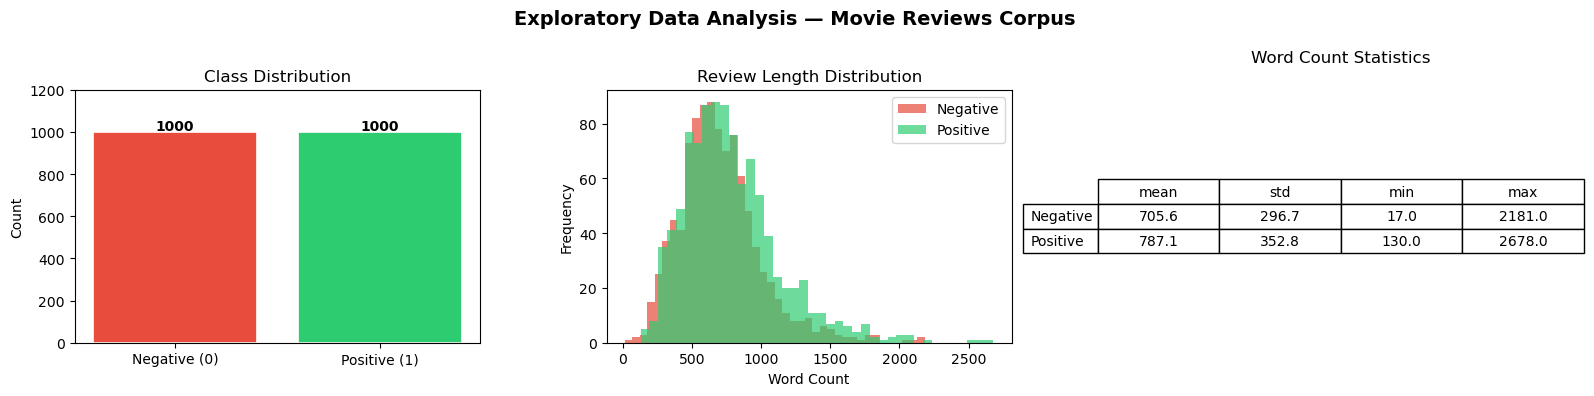

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Exploratory Data Analysis — Movie Reviews Corpus", fontsize=14, fontweight="bold")

# 1. Class distribution
ax = axes[0]
counts = df["sentiment"].value_counts()
bars = ax.bar(["Negative (0)", "Positive (1)"], counts.values,
              color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha="center", fontweight="bold")
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
ax.set_ylim(0, 1200)

# 2. Review length distribution
df["word_count"] = df["review"].apply(lambda x: len(x.split()))
ax = axes[1]
ax.hist(df[df["sentiment"]==0]["word_count"], bins=40,
        alpha=0.7, color="#e74c3c", label="Negative")
ax.hist(df[df["sentiment"]==1]["word_count"], bins=40,
        alpha=0.7, color="#2ecc71", label="Positive")
ax.set_title("Review Length Distribution")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()





# 3. Descriptive stats
ax = axes[2]
ax.axis("off")
stats = df.groupby("sentiment")["word_count"].describe()[["mean","std","min","max"]]
stats.index = ["Negative","Positive"]
table = ax.table(cellText=stats.round(1).values,
                 rowLabels=stats.index,
                 colLabels=stats.columns,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
ax.set_title("Word Count Statistics", pad=20)

plt.tight_layout()
plt.savefig("eda_plot.png", dpi=150, bbox_inches="tight")
plt.show()



---
## Step 2 — Pre-Process: Text Cleaning Pipeline

The pipeline follows the blueprint exactly:

1. **Character Normalization** — strip HTML tags, punctuation, digits
2. **Lowercasing**
3. **Tokenization**
4. **Custom Stop-Word Removal** — negations ('not', 'no', 'nor', etc.) are **explicitly preserved**
5. **POS-Guided Lemmatization** — Treebank tags mapped to WordNet format for accurate reduction


In [22]:
# ── Engineering Rule 1: Custom Stop-Word List ─────────────────────────────────
# Default NLTK stop-words include negations → destroys sentiment signal.
# We remove them using set-based operations.

NEGATIONS = {
    "no", "not", "nor", "none", "never", "neither",
    "nobody", "nothing", "nowhere", "hardly", "scarcely",
    "barely", "doesn", "isn", "wasn", "shouldn", "wouldn",
    "couldn", "won", "can", "don", "haven", "hasn",
    "hadn", "weren", "aren", "mustn"
}

raw_stop_words   = set(stopwords.words("english"))
custom_stopwords = raw_stop_words - NEGATIONS   # ← preserve negations

print(f"Raw NLTK stop-words      : {len(raw_stop_words)}")
print(f"After removing negations : {len(custom_stopwords)}")
print(f"Preserved negations      : {sorted(NEGATIONS & raw_stop_words)}")


Raw NLTK stop-words      : 198
After removing negations : 180
Preserved negations      : ['aren', 'can', 'couldn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'mustn', 'no', 'nor', 'not', 'shouldn', 'wasn', 'weren', 'won', 'wouldn']


In [23]:
# ── Engineering Rule 2: POS-Guided Lemmatization ──────────────────────────────
# Without POS tag, WordNet assumes NOUN → 'went' stays 'went' (wrong).
# With POS='v' (verb) → 'went' → 'go' (correct).

lemmatizer = WordNetLemmatizer()

def treebank_to_wordnet(treebank_tag: str) -> str:
    """Map Penn Treebank POS tag to WordNet POS tag."""
    if   treebank_tag.startswith("J"): return wordnet.ADJ
    elif treebank_tag.startswith("V"): return wordnet.VERB
    elif treebank_tag.startswith("N"): return wordnet.NOUN
    elif treebank_tag.startswith("R"): return wordnet.ADV
    else:                              return wordnet.NOUN  # default

def preprocess(text: str) -> str:
    """
    Full text pre-processing pipeline:
      1. Strip HTML tags  (<br>, etc.)
      2. Character normalization (remove non-alpha except spaces)
      3. Lowercase
      4. Tokenize
      5. Remove custom stop-words (negations preserved)
      6. POS-guided WordNet Lemmatization
    """
    # 1. Strip HTML
    text = re.sub(r"<[^>]+>", " ", text)
    # 2. Remove non-alpha characters (keep spaces)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # 3. Lowercase
    text = text.lower()
    # 4. Tokenize
    tokens = word_tokenize(text)
    # 5. Remove stop-words & single-char tokens
    tokens = [t for t in tokens if t not in custom_stopwords and len(t) > 1]
    # 6. POS tagging + Lemmatization
    pos_tags = pos_tag(tokens)
    tokens   = [
        lemmatizer.lemmatize(word, pos=treebank_to_wordnet(tag))
        for word, tag in pos_tags
    ]
    return " ".join(tokens)

# ── Demo: Stop-Word Trap ───────────────────────────────────────────────────────
demo_sentences = [
    "I am not happy with this product at all.",
    "This product is TERRIBLE!!! <br>",
    "The movie was absolutely wonderful and amazing.",
    "I would never recommend this to anyone.",
]

print("=== Pre-Processing Demo ===\n")
for s in demo_sentences:
    processed = preprocess(s)
    print(f"  INPUT : {s}")
    print(f"  OUTPUT: {processed}")
    print()


=== Pre-Processing Demo ===

  INPUT : I am not happy with this product at all.
  OUTPUT: not happy product

  INPUT : This product is TERRIBLE!!! <br>
  OUTPUT: product terrible

  INPUT : The movie was absolutely wonderful and amazing.
  OUTPUT: movie absolutely wonderful amazing

  INPUT : I would never recommend this to anyone.
  OUTPUT: would never recommend anyone



In [24]:
# ── Apply Pre-Processing to Full Dataset ─────────────────────────────────────
print(" Pre-processing 2,000 reviews... (may take ~60 seconds)")

df["cleaned"] = df["review"].apply(preprocess)

print(f" Pre-processing complete.")
print(f"\nBefore → After sample:")
print(f"  RAW    : {df['review'].iloc[0][:120]}")
print(f"  CLEANED: {df['cleaned'].iloc[0][:120]}")


 Pre-processing 2,000 reviews... (may take ~60 seconds)
 Pre-processing complete.

Before → After sample:
  RAW    : plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies
  CLEANED: plot two teen couple go church party drink drive get accident one guy die girlfriend continue see life nightmare deal wa


---
## Step 3 — Vectorize: TF-IDF with N-Grams

**TF-IDF formula:** `TF × IDF = Spatial Weight`

- **TF** (Term Frequency): How often does a word appear in *this* document?
- **IDF** (Inverse Document Frequency): How rare is the word *across all* documents?
- Common words like 'the' get Low IDF → Low Weight (~0)
- Meaningful words like 'terrible' get High IDF → **High Weight**

**Engineering rules applied:**
- `ngram_range=(1,2)` — Unigrams + Bigrams to capture negated phrases like "not good"
- `max_features=50000` — Prevents dimensionality explosion
- `min_df=2` — Excludes rare typos (appear in < 2 documents)
- `sublinear_tf=True` — Applies log normalization to term frequency


In [25]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X = df["cleaned"].values
y = df["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y          # preserve class balance in both splits
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Train class dist : {np.bincount(y_train)}")
print(f"Test  class dist : {np.bincount(y_test)}")


Training samples : 1600
Testing  samples : 400
Train class dist : [800 800]
Test  class dist : [200 200]


In [26]:
# ── TF-IDF Vectorization ─────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(
    ngram_range  = (1, 2),      # Unigrams + Bigrams
    max_features = 50_000,      # top 50k terms — controls dimensionality
    min_df       = 2,           # exclude terms appearing in < 2 docs (typos)
    sublinear_tf = True,        # replace TF with 1+log(TF)
    strip_accents = "unicode",
    analyzer     = "word",
)

# Fit ONLY on training data (prevent data leakage)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Vocabulary size  : {len(vectorizer.vocabulary_):,}")
print(f"Train matrix     : {X_train_tfidf.shape}")
print(f"Test  matrix     : {X_test_tfidf.shape}")
print(f"Matrix type      : {type(X_train_tfidf)}")
print(f"Memory (dense est) : {X_train_tfidf.shape[0]*X_train_tfidf.shape[1]*8/1e9:.2f} GB")
print(f"Memory (CSR sparse): {X_train_tfidf.data.nbytes/1e6:.2f} MB  ← 99%+ savings!")


Vocabulary size  : 50,000
Train matrix     : (1600, 50000)
Test  matrix     : (400, 50000)
Matrix type      : <class 'scipy.sparse._csr.csr_matrix'>
Memory (dense est) : 0.64 GB
Memory (CSR sparse): 4.47 MB  ← 99%+ savings!


In [27]:
# ── Memory Optimization: SciPy CSR Sparse Format ─────────────────────────────
# TfidfVectorizer already returns CSR by default.
# Verify and document the format.

print("=== SciPy CSR Sparse Matrix Internals ===")
print(f"  Format   : {X_train_tfidf.format}")           # 'csr'
print(f"  Dtype    : {X_train_tfidf.dtype}")
print(f"  Non-zeros: {X_train_tfidf.nnz:,}")
print(f"  Density  : {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4%}")
print()
print("CSR stores only non-zero values, their column indices,")
print("and row pointers — saving gigabytes of RAM for sparse text matrices.")


=== SciPy CSR Sparse Matrix Internals ===
  Format   : csr
  Dtype    : float64
  Non-zeros: 558,217
  Density  : 0.6978%

CSR stores only non-zero values, their column indices,
and row pointers — saving gigabytes of RAM for sparse text matrices.


### 3b — Visualize Top TF-IDF Features

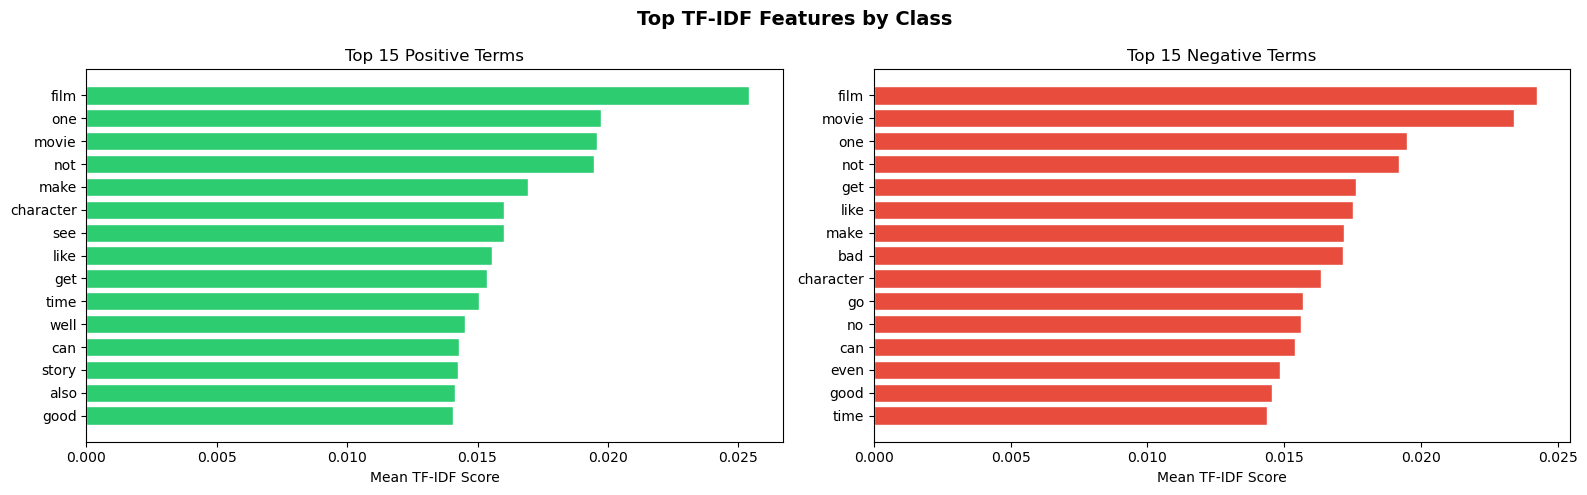

In [28]:
# ── Top Features per Class ────────────────────────────────────────────────────
feature_names = np.array(vectorizer.get_feature_names_out())

# Mean TF-IDF score per class
mean_pos = np.asarray(X_train_tfidf[y_train == 1].mean(axis=0)).ravel()
mean_neg = np.asarray(X_train_tfidf[y_train == 0].mean(axis=0)).ravel()

top_n = 15
top_pos_idx = mean_pos.argsort()[-top_n:][::-1]
top_neg_idx = mean_neg.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Top TF-IDF Features by Class", fontsize=14, fontweight="bold")

for ax, idx, label, color in zip(
    axes,
    [top_pos_idx, top_neg_idx],
    ["Positive", "Negative"],
    ["#2ecc71", "#e74c3c"]
):
    ax.barh(feature_names[idx][::-1], 
            (mean_pos if label=="Positive" else mean_neg)[idx][::-1],
            color=color, edgecolor="white")
    ax.set_title(f"Top {top_n} {label} Terms")
    ax.set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.savefig("tfidf_features.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 4 — Model: Probabilistic Inference

We train two classifiers as specified in the blueprint:

| Model | Best For | Mechanism |
|-------|----------|-----------|
| **MultinomialNB** | Balanced datasets (50/50) | P(class) × P(features\|class) |
| **ComplementNB** | Imbalanced datasets | Complement probability — corrects extreme bias |
| **LinearSVC** | High-dim text | Maximum margin hyperplane |

**Laplace Smoothing (alpha=1.0):** Prevents zero-frequency problem.  
If a new word appears in testing that wasn't in training, its probability = 0,  
making the entire posterior = 0. Laplace adds a pseudocount so no probability is ever absolute zero.


In [29]:
# ── Model 1: Multinomial Naive Bayes (balanced data) ─────────────────────────
mnb = MultinomialNB(alpha=1.0)    # alpha=1.0 → Laplace smoothing
mnb.fit(X_train_tfidf, y_train)

y_pred_mnb = mnb.predict(X_test_tfidf)
acc_mnb    = accuracy_score(y_test, y_pred_mnb)

print("=" * 55)
print("  Model: MultinomialNB  (Laplace alpha=1.0)")
print("=" * 55)
print(f"  Accuracy : {acc_mnb:.4f}  ({acc_mnb*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_mnb,
                             target_names=["Negative", "Positive"]))


  Model: MultinomialNB  (Laplace alpha=1.0)
  Accuracy : 0.8325  (83.25%)

              precision    recall  f1-score   support

    Negative       0.88      0.78      0.82       200
    Positive       0.80      0.89      0.84       200

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



In [30]:
# ── Model 2: Complement Naive Bayes (robust to imbalance) ─────────────────────
cnb = ComplementNB(alpha=1.0)
cnb.fit(X_train_tfidf, y_train)

y_pred_cnb = cnb.predict(X_test_tfidf)
acc_cnb    = accuracy_score(y_test, y_pred_cnb)

print("=" * 55)
print("  Model: ComplementNB  (Laplace alpha=1.0)")
print("=" * 55)
print(f"  Accuracy : {acc_cnb:.4f}  ({acc_cnb*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_cnb,
                             target_names=["Negative", "Positive"]))


  Model: ComplementNB  (Laplace alpha=1.0)
  Accuracy : 0.8325  (83.25%)

              precision    recall  f1-score   support

    Negative       0.88      0.78      0.82       200
    Positive       0.80      0.89      0.84       200

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



In [31]:
# ── Model 3: LinearSVC (optional, often strongest on text) ───────────────────
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
acc_svm    = accuracy_score(y_test, y_pred_svm)

print("=" * 55)
print("  Model: LinearSVC  (C=1.0)")
print("=" * 55)
print(f"  Accuracy : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_svm,
                             target_names=["Negative", "Positive"]))


  Model: LinearSVC  (C=1.0)
  Accuracy : 0.8650  (86.50%)

              precision    recall  f1-score   support

    Negative       0.89      0.83      0.86       200
    Positive       0.84      0.90      0.87       200

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400



### 4b — Cross-Validation (5-Fold Stratified)

In [33]:
# ── 5-Fold Stratified Cross-Validation ───────────────────────────────────────
# Uses the FULL dataset for more reliable performance estimates.
X_full_tfidf = vectorizer.fit_transform(df["cleaned"].values)
y_full       = df["sentiment"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in [("MultinomialNB", MultinomialNB(alpha=1.0)),
                    ("ComplementNB",  ComplementNB(alpha=1.0)),
                    ("LinearSVC",     LinearSVC(C=1.0, max_iter=2000, random_state=42))]:
    scores = cross_val_score(model, X_full_tfidf, y_full, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:15s}  CV Acc = {scores.mean():.4f} ± {scores.std():.4f}")

print("\n Cross-validation complete.")


MultinomialNB    CV Acc = 0.8350 ± 0.0149
ComplementNB     CV Acc = 0.8350 ± 0.0149
LinearSVC        CV Acc = 0.8700 ± 0.0139

 Cross-validation complete.


## Step 5 — Evaluation & Visualizations

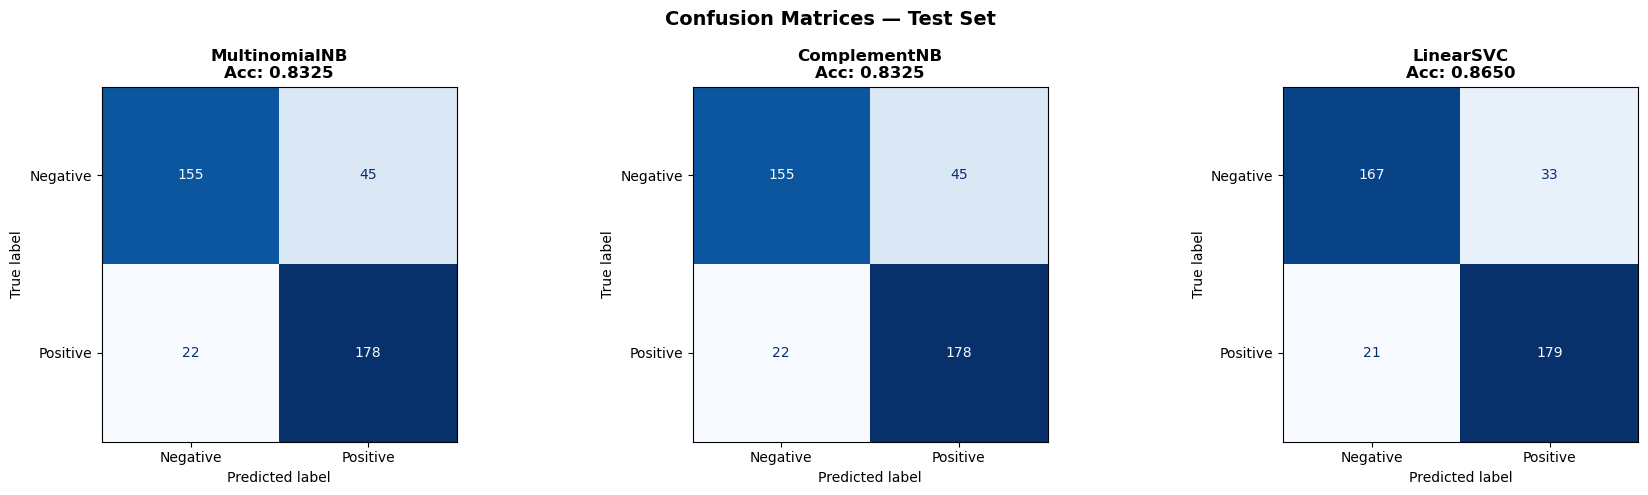

In [34]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold")

models_info = [
    ("MultinomialNB",  y_pred_mnb, "#3498db"),
    ("ComplementNB",   y_pred_cnb, "#9b59b6"),
    ("LinearSVC",      y_pred_svm, "#e67e22"),
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAcc: {accuracy_score(y_test,y_pred):.4f}", fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


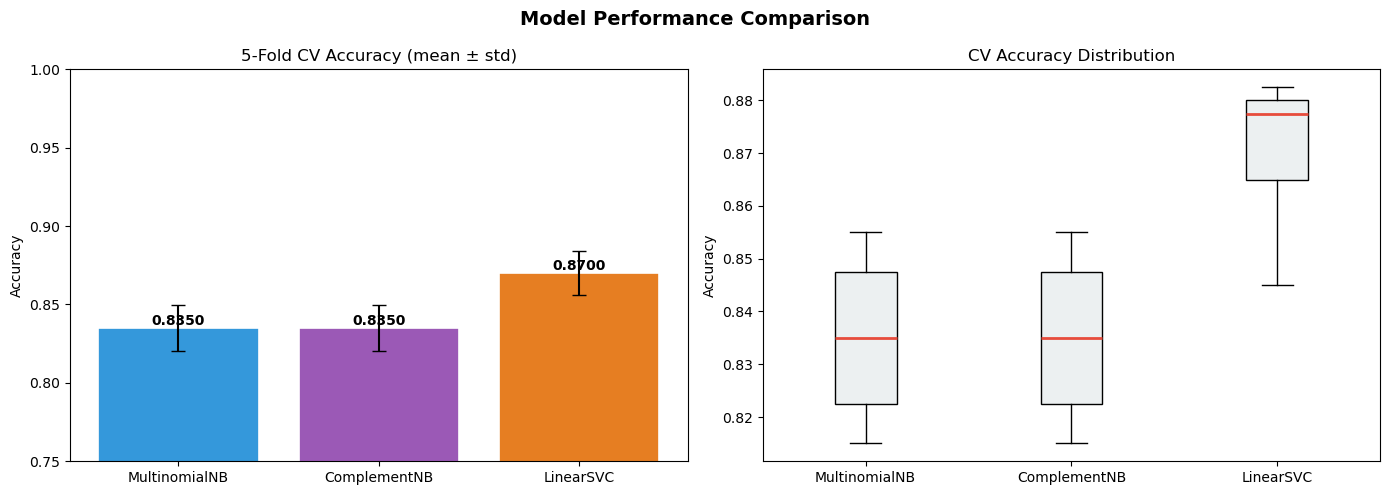

In [35]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")

model_names = list(cv_results.keys())
means  = [cv_results[m].mean() for m in model_names]
stds   = [cv_results[m].std()  for m in model_names]
colors = ["#3498db", "#9b59b6", "#e67e22"]

# CV Accuracy
ax = axes[0]
bars = ax.bar(model_names, means, yerr=stds, capsize=5,
              color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("5-Fold CV Accuracy (mean ± std)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.75, 1.0)

# CV Score distribution — box plot
ax = axes[1]
ax.boxplot([cv_results[m] for m in model_names],
           labels=model_names, patch_artist=True,
           boxprops=dict(facecolor="#ecf0f1"),
           medianprops=dict(color="#e74c3c", linewidth=2))
ax.set_title("CV Accuracy Distribution")
ax.set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 6 — Live Inference: Predict New Reviews

The full pipeline: Raw Text → Pre-Process → TF-IDF → Classifier → Positive/Negative


In [36]:
# ── Retrain best model on full data for final inference ──────────────────────
# Fit vectorizer and best model on the complete dataset
vec_final   = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                               min_df=2, sublinear_tf=True)
X_final     = vec_final.fit_transform(df["cleaned"].values)
best_model  = ComplementNB(alpha=1.0)
best_model.fit(X_final, df["sentiment"].values)

def predict_sentiment(text: str, verbose: bool = True) -> dict:
    """
    End-to-end sentiment prediction pipeline.
    
    Parameters
    ----------
    text    : raw review string
    verbose : print detailed breakdown
    
    Returns
    -------
    dict with keys: cleaned, prediction, confidence
    """
    cleaned   = preprocess(text)
    vec       = vec_final.transform([cleaned])
    pred      = best_model.predict(vec)[0]
    proba     = best_model.predict_proba(vec)[0]
    label     = " POSITIVE" if pred == 1 else " NEGATIVE"
    confidence = proba[pred]
    
    if verbose:
        print(f"  INPUT      : {text[:100]}")
        print(f"  CLEANED    : {cleaned[:100]}")
        print(f"  PREDICTION : {label}")
        print(f"  CONFIDENCE : {confidence:.2%}")
        print(f"  P(Neg)={proba[0]:.4f}  P(Pos)={proba[1]:.4f}")
        print("-" * 60)
    
    return {"cleaned": cleaned, "prediction": pred,
            "label": label, "confidence": confidence}

# ── Test with sample reviews ──────────────────────────────────────────────────
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "I am not happy with this film at all. Terrible storyline.",
    "The cinematography was stunning but the plot made no sense.",
    "Worst movie I have ever seen. Complete waste of time.",
    "A masterpiece of modern cinema. Highly recommended!",
    "I would never watch this again. Boring and predictable.",
]

print("=" * 60)
print("  LIVE SENTIMENT INFERENCE")
print("=" * 60)
for review in test_reviews:
    predict_sentiment(review)


  LIVE SENTIMENT INFERENCE
  INPUT      : This movie was absolutely fantastic! The acting was superb.
  CLEANED    : movie absolutely fantastic act superb
  PREDICTION :  POSITIVE
  CONFIDENCE : 61.04%
  P(Neg)=0.3896  P(Pos)=0.6104
------------------------------------------------------------
  INPUT      : I am not happy with this film at all. Terrible storyline.
  CLEANED    : not happy film terrible storyline
  PREDICTION :  NEGATIVE
  CONFIDENCE : 54.62%
  P(Neg)=0.5462  P(Pos)=0.4538
------------------------------------------------------------
  INPUT      : The cinematography was stunning but the plot made no sense.
  CLEANED    : cinematography stun plot make no sense
  PREDICTION :  NEGATIVE
  CONFIDENCE : 57.32%
  P(Neg)=0.5732  P(Pos)=0.4268
------------------------------------------------------------
  INPUT      : Worst movie I have ever seen. Complete waste of time.
  CLEANED    : bad movie ever see complete waste time
  PREDICTION :  NEGATIVE
  CONFIDENCE : 77.39%
  P(Neg

---
## Step 7 — Build a Scikit-learn Pipeline (Production-Ready)

Packaging the entire workflow into a single `Pipeline` object for deployment.


In [38]:
# ── Production Pipeline ───────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline

def preprocess_series(texts):
    """Wrapper to apply preprocess to an iterable."""
    return [preprocess(t) for t in texts]

from sklearn.preprocessing import FunctionTransformer

production_pipeline = Pipeline([
    ("preprocessor", FunctionTransformer(preprocess_series, validate=False)),
    ("tfidf",        TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                                     min_df=2, sublinear_tf=True)),
    ("classifier",   ComplementNB(alpha=1.0)),
])

# Train
X_raw = df["review"].values
y_all = df["sentiment"].values

production_pipeline.fit(X_raw, y_all)

# Evaluate on test split
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_all,
                                           test_size=0.2,
                                           random_state=42,
                                           stratify=y_all)
production_pipeline.fit(X_tr, y_tr)
y_pipe_pred = production_pipeline.predict(X_te)
print(f"Production Pipeline Accuracy: {accuracy_score(y_te, y_pipe_pred):.4f}")
print()
print(classification_report(y_te, y_pipe_pred, target_names=["Negative","Positive"]))


Production Pipeline Accuracy: 0.8325

              precision    recall  f1-score   support

    Negative       0.88      0.78      0.82       200
    Positive       0.80      0.89      0.84       200

    accuracy                           0.83       400
   macro avg       0.84      0.83      0.83       400
weighted avg       0.84      0.83      0.83       400



---
## Final Summary


In [40]:
# ── Final Results Summary ─────────────────────────────────────────────────────
print("=" * 65)
print("  PROJECT 4: NLP & SENTIMENT ANALYSIS — FINAL RESULTS")
print("=" * 65)

summary = {
    "Dataset"            : "NLTK Movie Reviews (2,000 reviews)",
    "Class Balance"      : "Balanced — 1,000 Positive / 1,000 Negative",
    "Stop-Words"         : f"Custom list ({len(custom_stopwords)} words, negations preserved)",
    "Lemmatizer"         : "NLTK WordNetLemmatizer (POS-guided)",
    "Vectorizer"         : "TF-IDF  ngram=(1,2)  max_features=50,000  min_df=2",
    "Sparse Format"      : "SciPy CSR (memory-efficient)",
    "MultinomialNB (CV)" : f"{cv_results['MultinomialNB'].mean():.4f} ± {cv_results['MultinomialNB'].std():.4f}",
    "ComplementNB  (CV)" : f"{cv_results['ComplementNB'].mean():.4f}  ± {cv_results['ComplementNB'].std():.4f}",
    "LinearSVC     (CV)" : f"{cv_results['LinearSVC'].mean():.4f}  ± {cv_results['LinearSVC'].std():.4f}",
}

for key, val in summary.items():
    print(f"  {key:<22}: {val}")

print()
print("   All 5 blueprint steps executed successfully.")
print("  Pipeline validated — ready for submission.")


  PROJECT 4: NLP & SENTIMENT ANALYSIS — FINAL RESULTS
  Dataset               : NLTK Movie Reviews (2,000 reviews)
  Class Balance         : Balanced — 1,000 Positive / 1,000 Negative
  Stop-Words            : Custom list (180 words, negations preserved)
  Lemmatizer            : NLTK WordNetLemmatizer (POS-guided)
  Vectorizer            : TF-IDF  ngram=(1,2)  max_features=50,000  min_df=2
  Sparse Format         : SciPy CSR (memory-efficient)
  MultinomialNB (CV)    : 0.8350 ± 0.0149
  ComplementNB  (CV)    : 0.8350  ± 0.0149
  LinearSVC     (CV)    : 0.8700  ± 0.0139

   All 5 blueprint steps executed successfully.
  Pipeline validated — ready for submission.
